## Independent samples (The Mann–Whitney U/Wilcoxon Rank Sum)

The t-test is valid only when the data within each group (for an independent-samples t-test), or the pairwise differences (for a paired-samples t-test), are Normally distributed. As we have seen in the lectures, many real-life data distributions are approximately Normal, but many others are not. 

*When the Normality assumption is not met, we can use *non-parametric* tests, which do not assume that the data are drawn from a Normal distribution.*

**The Mann–Whitney U** test (also known as the **Wilcoxon Rank Sum** test) is used to test for a difference in median between two **independent samples**. As such, it is often considered a non-parametric alternative to the independent-samples t-test.

The terms *Mann–Whitney U* and *Wilcoxon Rank Sum* are used interchangeably in much of the literature and in many statistical packages, although technically the Mann–Whitney formulation (which was introduced slightly later) is valid in a wider range of cases.

In Python, the function we will use is called `mannwhitneyu`, but you may encounter the same test elsewhere referred to as the Rank Sum test or the Wilcoxon Rank Sum test.


## Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings 
warnings.simplefilter('ignore', category=FutureWarning)

## Example: motor learning and visualization

A researcher hypothesises that, when a person learns a new motor skill, imaginary practice (visualising performing the skill between sessions of actual practice) can enhance learning.

She tests this by training people to juggle. Participants complete 1 hour practice sessions each day until they can juggle for 2 minutes without dropping a ball. Participants are randomly assigned to one of two groups: the **Visualisation** group (who spend time between sessions visualising juggling) and the **Standard** group (who do not).

For each participant the researcher records the **number of sessions** required to reach the criterion (2 minutes without dropping a ball).

**Question:** test the hypothesis that visualisation reduces the number of sessions required to reach criterion.

*Notes:*
- Because participants are randomly assigned, the two groups are independent.
- The outcome (number of sessions) is a positive integer and is commonly skewed, so the Normality assumption for a t-test may not hold (but you should look at the data to confirm this).
- A rank-based test such as the **Mann–Whitney U** (Wilcoxon rank-sum) test is a suitable choice. It compares the distributions (and, in practice, medians) between the two independent groups and is robust to skew and outliers.
- Decide whether you want a **one-sided** or **two-sided** test. The directional hypothesis (“visualisation **reduces** sessions”) justifies a **one-sided** test in favour of the Visualisation group having smaller values.

*Practical steps*
1. Inspect the data (histograms / boxplots) for skewness and outliers.  
2. State the formal hypothesis
3. Report the Descriptive Statistics
4. Run the Mann–Whitney U test.  
5. Draw Conclusions

### 1. Inspect the data

The data are provided in a text (.csv) file.

Let's load the data as a Pandas dataframe, and plot them to get a sense for their distribution (is it normal?) and any outliers

In [2]:
# load the data and have a look
juggling=pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/juggling.csv')
juggling

,Group,SessionsToCriterion
0,Standard,15
1,Standard,14
2,Standard,15
3,Standard,8
4,Standard,7
5,Standard,22
6,Standard,36
7,Standard,19
8,Standard,14
9,Standard,18


Let's plot the data to get an idea of the distribution and check for outliers.

As we saw in the session on plotting, a good choice here will be a KDE plot (to get an estimate of the shape of the distribution) and a rug plot (individual data values as the KDE plot is based on only a small sample)

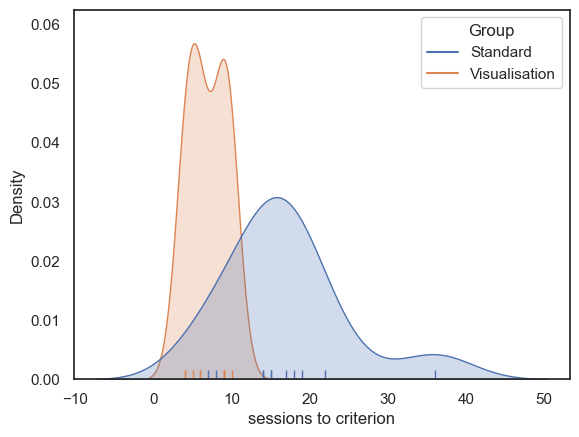

In [3]:
# Plot the KDE (distribution)
sns.kdeplot(data=juggling, x='SessionsToCriterion', hue='Group', fill=True)
sns.rugplot(data=juggling, x='SessionsToCriterion', hue='Group')

# axis labels
plt.xlabel("sessions to criterion", fontsize = 12)
plt.ylabel("Density", fontsize = 12)

plt.show()

Some participants (particularly in the Standard group) took much longer to reach criterion, resulting in a positively skewed distribution. This may be because it is possible for an individual to take many more than the median number of sessions to reach criterion, but impossible to take many fewer, since the number of sessions cannot be less than zero (the data are *bounded below*).

We therefore turn to the non-parametric **Rank Sum** test.

### 2. Hypotheses

$\mathcal{H_o}$: the <b>median</b> number of sessions needed is the same for participants in the Visualisation and Standard Groups

$\mathcal{H_a}$:the <b>median</b> number of sessions is lower for participants in the Visualisation Group
    
This is a one tailed test as the hypothesis is directional (we expect visualisation to help not hinder)

We will test at the $\alpha = 0.05$ significance level

* note we are testing for a difference of medians here, not a difference of means!

### 3. Descriptive statistics

Next we need to obtain some relevant descriptive statistics.

Because we are testing for a difference in medians, we focus on the median for each group. It is also useful to report a measure of spread and the sample size for each group. We can achieve this using `groupby` and `.describe()`


In [4]:
juggling.groupby(['Group']).describe()

SessionsToCriterion                                              \
                            count       mean       std  min   25%   50%   75%   
Group                                                                           
Standard                     11.0  16.818182  7.730694  7.0  14.0  15.0  18.5   
Visualisation                 9.0   6.888889  2.368778  4.0   5.0   6.0   9.0   

                     
                max  
Group                
Standard       36.0  
Visualisation  10.0

The median number of sessions to reach criterion is lower in the **Visualisation** group than in the **Standard** group:

- **Visualisation group:** median = 6, Q1 = 5, Q3 = 9, \(n = 9\)  
- **Standard group:** median = 15, Q1 = 14, Q3 = 18.5, \(n = 11\)


### 4. Carry out the test

We carry out the test using the function `stats.mannwhitneyu()` from `scipy.stats`.

The inputs to `stats.mannwhitneyu()` are:
- the two samples to be compared (the values of `SessionsToCriterion` from our Pandas DataFrame `juggling`, grouped according to the `Group` column);
- the argument `alternative='greater'`, which specifies a one-tailed test in which the median of the first input (the **Standard** group) is expected to be greater than that of the second input (the **Visualisation** group).

The outputs are the value of the test statistic ($U=91$)  and the associated <tt>pvalue</tt> ($p=0.00089$). Because this p-value is less than our chosen significance level $\alpha = 0.05$ , we conclude that there is a statistically significant difference between the groups.

More explanation of how the $U$ statistic is calculated is given below.

In [5]:
stats.mannwhitneyu(juggling.query('Group=="Standard"').SessionsToCriterion, 
                   juggling.query('Group=="Visualisation"').SessionsToCriterion,
                   alternative='greater')



#Note you may find it easier to read the code if you first save the two groups as separate variables:
#standard = juggling.query('Group=="Standard"').SessionsToCriterion
#visualisation = juggling.query('Group=="Visualisation"').SessionsToCriterion

#stats.mannwhitneyu(standard, visualisation, alternative='greater')

#This code wil give you the same result

MannwhitneyuResult(statistic=np.float64(91.0), pvalue=np.float64(0.0008910429856493874))

### 5. Draw conclusions

Because the <tt>pvalue</tt> ($p=0.00089$) is less than our chosen significance level ($\alpha = 0.05$), the test is considered statistically significant.

We therefore conclude that the median number of sessions required to reach criterion is greater in the **Standard** training group than in the **Visualisation** group.


## How does the Mann–Whitney U test work?

You have seen how to run the Mann–Whitney test using `scipy.stats`, but that may not make it any clearer how the computer actually arrived at the test statistic and p-value.

In this section we will build our own, step-by-step version of the test so you can see exactly what is being computed and why.


### Step 1: Convert the data to ranks

As seen in the lecture, the key step in the Mann–Whitney test is to replace the original data values with their ranks.

From these ranks we then compute a summary statistic, $U$ (closely related to the rank-sum statistic $R$), which roughly indicates what proportion of the higher ranks fall into one of the experimental groups.

The null distribution of $U$ (or $R$) depends only on the sample sizes, not on the data themselves. In this case our samples have sizes $n_1 = 11$ and $n_2 = 9$, and the null distribution of $U$ would be the same for *any* data with these sample sizes.

Note also that ranks are much less affected by outliers than the raw data values. For example, whether the lowest data value is one unit lower than the second-lowest value or a million units lower, they will still receive ranks 1 and 2.

We can rank the data using the `rank()` method in `pandas`, and add the resulting ranks as an extra column in our DataFrame.


In [6]:
juggling['Rank'] = juggling.SessionsToCriterion.rank()
juggling

,Group,SessionsToCriterion,Rank
0,Standard,15,14.5
1,Standard,14,12.5
2,Standard,15,14.5
3,Standard,8,7.0
4,Standard,7,6.0
5,Standard,22,19.0
6,Standard,36,20.0
7,Standard,19,18.0
8,Standard,14,12.5
9,Standard,18,17.0


It might be even clearer if we display the dataframe sorted by rank:

In [7]:
juggling.sort_values('Rank')

,Group,SessionsToCriterion,Rank
17,Visualisation,4,1.5
12,Visualisation,4,1.5
18,Visualisation,5,3.0
16,Visualisation,6,4.5
15,Visualisation,6,4.5
4,Standard,7,6.0
3,Standard,8,7.0
19,Visualisation,9,9.0
13,Visualisation,9,9.0
11,Visualisation,9,9.0


**Note the following:**

* The lowest value has rank 1 (or close to it)
* The highest value is assigned rank $n_1 + n_2$, that is, the total number of observations across both groups.
* Tied values are given the average of the ranks they would have got (e.g., ranks 1 and 2 are tied so both get 1.5)
* Many of the higher-ranked values belong to the **Standard** group, suggesting that many of the slowest participants to reach criterion were in this group.
* Many of the lower-ranked values belong to the **Visualisation** group, suggesting that many of the fastest participants to reach criterion were in this group.

### Calculate the test statistic

The test statistic is defined in terms of two quantities, $U_1$ and $U_2$. The value reported for the test is the larger of $U_1$ and $U_2$.

These are given by:

$U_1 = R_1 - \frac{n_1 (n_1 + 1)}{2}$

where:
* $R_1$ is the sum of the ranks in group 1
* $n_1$ is the sample size of group 1.

Similarly,

$U_2 = R_2 - \frac{n_2 (n_2 + 1)}{2}$

where:
* $R_2$ is the sum of the ranks in group 2
* $n_2$ is the sample size of group 2.

We can now define a function in Python to compute this statistic:


In [8]:
# This function computes the Mann–Whitney U statistic
# It takes two inputs:
#   x: a list or array of ranks for group x
#   y: a list or array of ranks for group y
# and returns the larger of Ux and Uy

def mwU(x, y):
    # Sum of ranks and sample size for group x
    Rx = sum(x)
    nx = len(x)
    
    # Compute U for group x
    Ux = Rx - (nx * (nx + 1)) / 2
    
    # Sum of ranks and sample size for group y
    Ry = sum(y)
    ny = len(y)
    
    # Compute U for group y
    Uy = Ry - (ny * (ny + 1)) / 2

    # Return the larger of the two U values
    return max(Ux, Uy)


Let's check it works on our juggling data. Our function `mwU` wants two sets of **ranks** as input:

In [9]:
mwU(juggling.query('Group=="Standard"').Rank, 
    juggling.query('Group=="Visualisation"').Rank)

91.0

Yay, it matches the output of `stats.mannwhitneyu()`!

* Are you confused what happened there? Look back to how we defined functions to get the difference of means or mean difference before running a permutation test.

### Establish the null distriubtion

As in the permutation test on data (rather than ranks), we can work out the null approximately by doing a lot of random 'deals' of the ranks to the Standard and Visualisation groups, calculating $U$ for each case, and work out in what proportion of cases this *simulated* $U$ was as large as, or larger than, the value of $U$ from our experiment.

* note that it is also possible to work out the distribution precisely, but this approach is pretty good and makes a clear analogy to permutation testing on data rather than ranks

We run the permutation test exactly as we did on the actual data data in the previous chapter


### Establish the null distribution

As with permutation tests applied to the raw data (rather than ranks), we can approximate the null distribution by repeatedly making random “deals” of the ranks between the Standard and Visualisation groups. For each random allocation, we calculate the value of $U$ and then determine the proportion of cases in which this *simulated* $U$ is as large as, or larger than, the value of $U$ observed in our experiment.

- Note that it is also possible to compute the null distribution exactly, but this simulation-based approach works well and makes a clear analogy with permutation testing on the raw data rather than on ranks.

We run this permutation procedure in exactly the same way as we did for the data-based permutation test in the previous chapter, only here we are providing the ranks and the function for calculating U as defined above.


In [10]:
results = stats.permutation_test((juggling.query('Group=="Standard"').Rank, 
                                  juggling.query('Group=="Visualisation"').Rank),
                                  mwU,
                                  alternative='greater',
                                  n_resamples=10000)

results

PermutationTestResult(statistic=np.float64(91.0), pvalue=np.float64(0.0006999300069993001), null_distribution=array([52.5, 56. , 51.5, ..., 58.5, 53. , 59.5], shape=(10000,)))

We get the same value of $U$ as from the function `stats.mannwhitneyu()`. The $p$-value is close too. Let's plot the null distribution of $U$

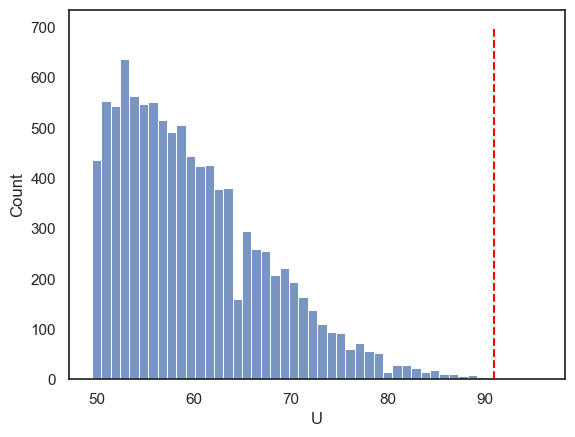

In [11]:
sns.histplot(results.null_distribution)
plt.xlabel('U')

plt.plot([results.statistic,results.statistic], [0,700], color='red', linestyle='--')
plt.show()

The null distribution is cut off at a minimum value of 49.5 because $U$ is defined as the *larger* of the two rank-sum–based statistics for the two groups. The smallest possible value of this larger statistic occurs when high and low ranks are shared as evenly as possible between the groups, which in this case gives a minimum of 49.5.

We can also verify that our p-value is simply the proportion of shuffled datasets for which $U \ge 91$.


In [12]:
np.mean(results.null_distribution>=91)

np.float64(0.0006)

Ta-daa!